# TCs 
### Logically merging TAs
#### There's two ways we could do this:
####  1. using some  clustering algorithm in 3D. 
####  2. using simplified nearest neighbour operations checks. 
### in principle   both of these would require some logical coordinate system. Ultimately the question is - what information do we want the TCs to encode

In [307]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import trigger_algs_numba as trg_numba
import utils as util
import uproot
import glob
import os

cc='orangered'; cl = 'steelblue'

#TAMaker parameters settings based on backgrounds - central config is default, lateral APAs require higher auto accept window threshold + cluster req. due to higher proportion of externals 
lat_params = { "accept_threshold": 130e3, "cluster_cut": 30e3 }



def load_data(filepath, tree_key):
    try:
        with uproot.open(filepath) as file:
            tree = file[tree_key]
            return tree.arrays(library='pd')
    except Exception as e:
        print(f"Error loading data from {filepath}: {e}")
        return None

def load_all_data(folder, tree_key):
    all_files = glob.glob(os.path.join(folder, "*.root"))
    dfs = [load_data(f, tree_key) for f in all_files]
    dfs = [df for df in dfs if df is not None]
    
    if not dfs:
        return None
    
    full_df = pd.concat(dfs, ignore_index=True)
    util.get_unique_event_ids(full_df)
    
    return full_df.sort_values(by="event_uid")



def load_all_tp_data(folder, tree_key):
    all_files = glob.glob(os.path.join(folder, "*.root"))
    dfs = []

    for f in all_files:
        df = load_data(f, tree_key)
        if df is None:
            continue

        mask = ( (df["samples_over_threshold"] > 8) &(df["readout_view"] == 2) &(df["adc_peak"] > 80))

        df_filtered = df[mask]

        if not df_filtered.empty:
            dfs.append(df_filtered)

    if not dfs:
        return None

    full_df = pd.concat(dfs, ignore_index=True) 
    util.get_unique_event_ids(full_df)

    return full_df.sort_values(by="event_uid")

cosmic_mc= pd.read_pickle("./cosmics/pkl/cosmic_mc_001.pkl")
cosmic_tps= pd.read_pickle("./cosmics/pkl/cosmic_tps_001.pkl")
cosmic_evsum = pd.read_pickle("./cosmics/pkl/cosmic_eventsum_001.pkl")
cosmic_mcparts = pd.read_pickle("./cosmics/pkl/cosmic_mcparticles_001.pkl") 


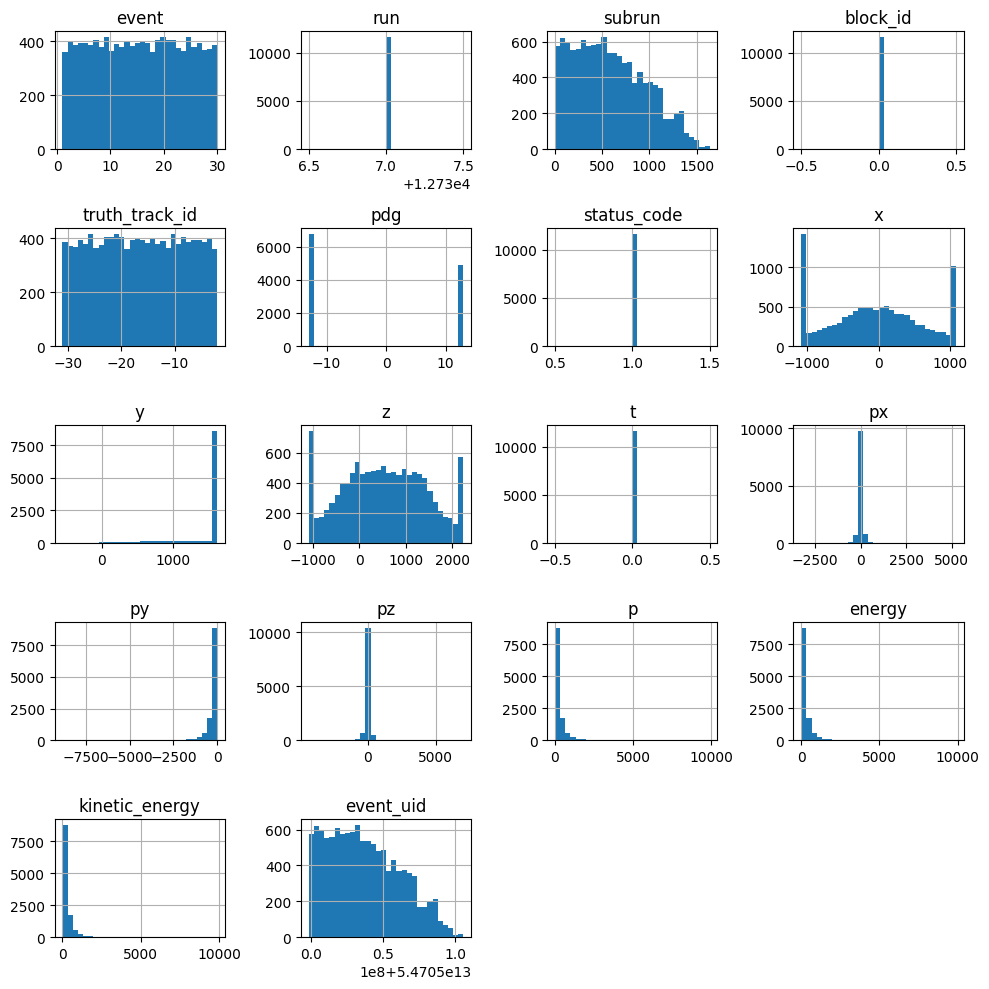

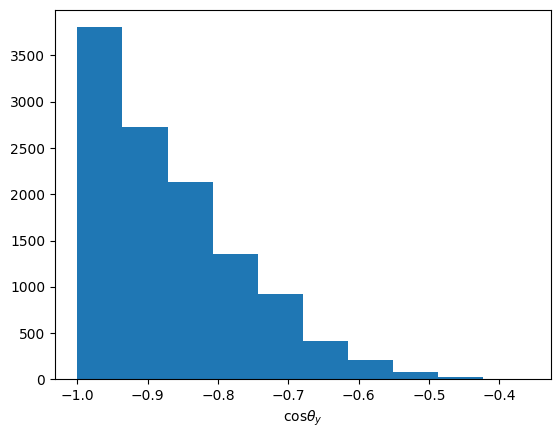

In [180]:
cosmic_mc.hist(bins =30, figsize= (10,10))
plt.tight_layout()
plt.show()


plt.hist(cosmic_mc.py/cosmic_mc.p)
plt.xlabel(r"cos$\theta_y$")
plt.show()

In [145]:
#Load MC beam info 
for data_type in ["mc", "nu", "sum"]:
    for part in ["nue", "numu"]:
        globals()[f"{part}_{data_type}"] = pd.read_pickle(f"./beam/genie_{part}_{data_type}.pkl")
        #get_unique_event_ids(globals()[f"{part}_{data_type}"])
        globals()[f"{part}_{data_type}"] = globals()[f"{part}_{data_type}"].sort_values(by="event_uid")

#Load TAs
for part in ["nue", "numu"]:
    globals()[f"trig_{part}_cent"] = pd.read_pickle(f"./trigger_data/beamTAs_{part}_cbgd.pkl")
    globals()[f"trig_{part}_lat"] = pd.read_pickle(f"./trigger_data/beamTAs_{part}_lbgd.pkl")

    globals()[f"beam_{part}_ctps"] = pd.read_pickle(f"./trigger_data/beam_chunks/{part}_TPs_cbgd_6.pkl")
 

    nu = globals()[f"{part}_nu"]
    mc = globals()[f"{part}_mc"]

    if part == "nue":
            mc = mc[(mc.pdg==12) & (mc.status_code==0)]
    else:
         mc =mc[(mc.pdg==14) & (mc.status_code==0)]

    globals()[f"trig_beam_{part}_lat"] = pd.merge(globals()[f"trig_{part}_lat"], nu[['event','run','mode','ccnc']], on=['event','run'], how='inner')
    globals()[f"trig_beam_{part}_cent"] = pd.merge(globals()[f"trig_{part}_cent"], nu[['event','run','mode','ccnc']], on=['event','run'], how='inner')

    globals()[f"trig_beam_{part}_lat"] = pd.merge(globals()[f"trig_beam_{part}_lat"], mc[['event','run','energy','x', 'y', 'z']], on=['event','run'], how='inner')
    globals()[f"trig_beam_{part}_cent"] = pd.merge(globals()[f"trig_beam_{part}_cent"], mc[['event','run','energy','x', 'y', 'z']], on=['event','run'], how='inner')


print("number of nu_e beam events: ", nue_sum.event_uid.nunique())
print("number of nu_mu beam events: ", numu_sum.event_uid.nunique())


    
display(trig_beam_nue_lat)

number of nu_e beam events:  94760
number of nu_mu beam events:  98620


,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,t_wstd,run,visible_energy,event_uid,mode,ccnc,energy,x,y,z
0,62661,10.0,20.0,2.0,2000.0,2.0,3.0,6702108.0,445.0,-1.0,...,196.442765,8528,2683.735514,36627481162949,1,0,4.310564,-201.113174,-65.517233,1234.464428
1,62661,10.0,20.0,2.0,3000.0,2.0,4.0,1170076.0,170.0,-1.0,...,123.301679,8528,2683.735514,36627481162949,1,0,4.310564,-201.113174,-65.517233,1234.464428
2,62661,11.0,22.0,2.0,1000.0,2.0,8.0,42111.0,3.0,1.0,...,1.111690,8528,2683.735514,36627481162949,1,0,4.310564,-201.113174,-65.517233,1234.464428
3,62661,10.0,20.0,2.0,4000.0,0.0,5.0,19254.0,6.0,1.0,...,0.450715,8528,2683.735514,36627481162949,1,0,4.310564,-201.113174,-65.517233,1234.464428
4,62661,11.0,22.0,2.0,0.0,0.0,7.0,20631.0,3.0,1.0,...,0.000000,8528,2683.735514,36627481162949,1,0,4.310564,-201.113174,-65.517233,1234.464428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371572,57619,9.0,19.0,3.0,2000.0,0.0,23843.0,35001.0,8.0,3.0,...,0.455212,8528,11149.659565,36627481157907,2,0,15.449240,-4.918258,99.956578,951.307108
371573,57619,9.0,19.0,3.0,3000.0,0.0,23844.0,16167.0,4.0,2.0,...,0.487605,8528,11149.659565,36627481157907,2,0,15.449240,-4.918258,99.956578,951.307108
371574,57619,11.0,22.0,2.0,1000.0,0.0,23847.0,57173.0,11.0,4.0,...,0.000000,8528,11149.659565,36627481157907,2,0,15.449240,-4.918258,99.956578,951.307108
371575,57619,11.0,23.0,3.0,1000.0,2.0,23850.0,84187.0,16.0,3.0,...,1.016639,8528,11149.659565,36627481157907,2,0,15.449240,-4.918258,99.956578,951.307108


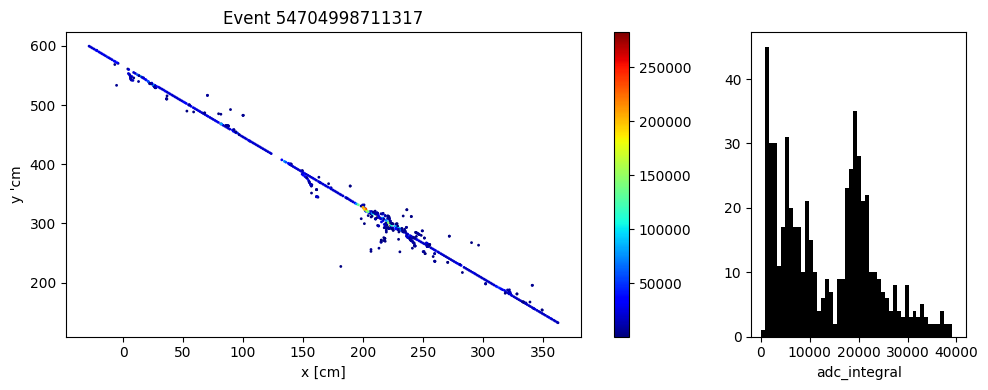

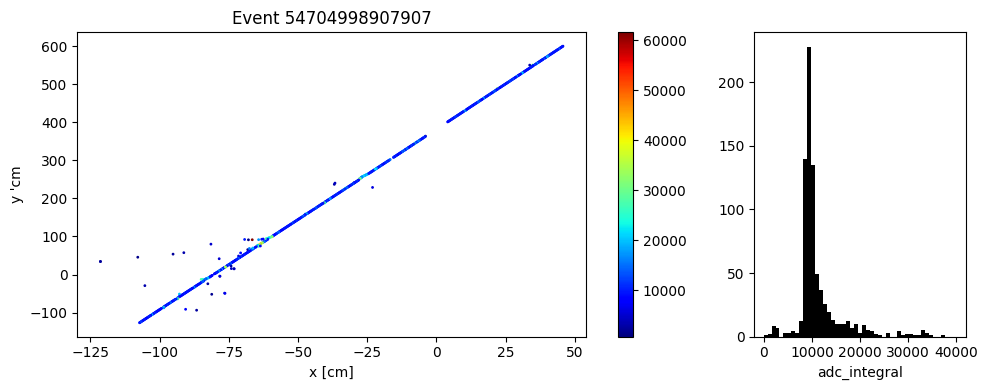

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for i in [18, 28]:
    ev = cosmic_tps.event_uid.unique()[i]
    x = cosmic_tps[(cosmic_tps.event_uid == ev) & (cosmic_tps.bt_edep > 0)]

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})
    axs[0].scatter(x.bt_x, x.bt_y, c=x.adc_integral, s=1, cmap='jet')
    axs[0].set_title(f"Event {ev}")
    axs[0].set_xlabel("x [cm]")
    axs[0].set_ylabel("y 'cm")
    fig.colorbar(axs[0].collections[0], ax=axs[0])

    axs[1].hist(x.adc_integral, bins=np.linspace(0, 40e3, 50), color='k')
    axs[1].set_xlabel("adc_integral")

    plt.tight_layout()
    plt.show()


In [338]:
#Map the TPC IDs to a 3D logical grid to be able to extract nearest neighbours within the TC using straight forward functions?? 
# Maps TPC id -> (ix, iy, iz)
TPC_ID_TO_INDEX = {
    0: (0, 0, 0),  1: (1, 0, 0),
    2: (0, 1, 0),  3: (1, 1, 0),
    4: (0, 0, 1),  5: (1, 0, 1),
    6: (0, 1, 1),  7: (1, 1, 1),
    8: (0, 0, 2),  9: (1, 0, 2),
   10: (0, 1, 2), 11: (1, 1, 2),
   12: (0, 0, 3), 13: (1, 0, 3),
   14: (0, 1, 3), 15: (1, 1, 3),
   16: (0, 0, 4), 17: (1, 0, 4),
   18: (0, 1, 4), 19: (1, 1, 4),
   20: (0, 0, 5), 21: (1, 0, 5),
   22: (0, 1, 5), 23: (1, 1, 5)
}

# Invert it if needed:
INDEX_TO_TPC_ID = {v: k for k, v in TPC_ID_TO_INDEX.items()}

cosmic_tps['original_event'] = cosmic_tps.event
cosmic_tps['event'] = cosmic_tps.event_uid

# make cosmic TAs: 
print("\n" + f"generating central APA efficiencies for cosmics")
cTPs_cosmic, cTAs_cosmic  = util.GenerateTAs(cosmic_tps)
print("\n" + f"generating lateral APA efficiencies for cosmics")
lTPs_cosmic, lTAs_cosmic  = util.GenerateTAs(cosmic_tps, **lat_params)

cTAs_cosmic['event_uid'] = cTAs_cosmic['event']
lTAs_cosmic['event_uid'] = lTAs_cosmic['event']

cosmic_evsum['visible_energy'] = cosmic_evsum.tot_visible_energy_rop2 + cosmic_evsum.tot_visible_energy_rop3 
trig_cosmic_cent =  pd.merge(cTAs_cosmic, cosmic_evsum[[ 'visible_energy', 'event_uid']], on=['event_uid'], how='right').fillna(-1)
trig_cosmic_lat =  pd.merge(lTAs_cosmic, cosmic_evsum[[ 'visible_energy', 'event_uid']], on=['event_uid'], how='right').fillna(-1)



display(trig_cosmic_cent)


generating central APA efficiencies for cosmics
Processing run 1/1


100%|██████████| 1786/1786 [00:00<00:00, 14031.40it/s]



generating lateral APA efficiencies for cosmics
Processing run 1/1


100%|██████████| 2693/2693 [00:00<00:00, 9142.36it/s] 


,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,t_mean,ch_std,t_std,ch_wmean,t_wmean,ch_wstd,t_wstd,run,event_uid,visible_energy
0,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54704998514690,0.000000
1,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54704998514691,0.000000
2,5.470500e+13,8.0,16.0,2.0,1000.0,2.0,3.0,2547704.0,57.0,-1.0,...,1765.842105,34.594205,211.479400,22194.920431,1638.055396,11.651623,224.193669,12737.0,54704998514692,7617.002653
3,5.470500e+13,8.0,16.0,2.0,2000.0,2.0,4.0,21771877.0,393.0,-1.0,...,2416.343511,26.456593,210.238533,22177.761849,2380.018631,9.704395,156.063325,12737.0,54704998514692,7617.002653
4,5.470500e+13,8.0,16.0,2.0,3000.0,2.0,5.0,1574396.0,37.0,-1.0,...,3250.243243,32.640974,104.976550,22163.383820,3213.382814,8.199116,98.558274,12737.0,54704998514692,7617.002653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30660,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54705105731595,0.000000
30661,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54705105731598,0.000000
30662,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54705105731602,0.000000
30663,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54705105731604,0.000000


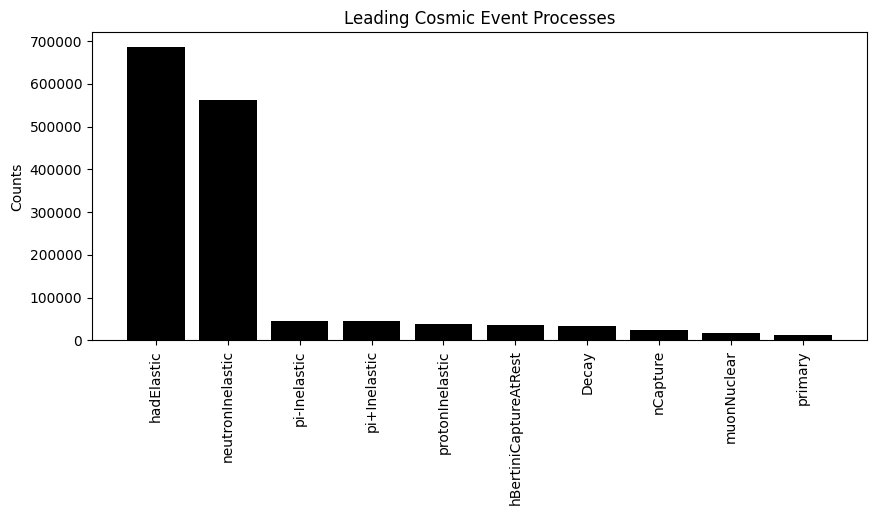

1000080160: 492434
22: 334847
2112: 180452
1000140280: 107420
2212: 87805
1000060120: 44459
1000130270: 31739
1000260560: 25343
1000180400: 23735
1000020040: 21823
11: 18446
1000120240: 15798
13: 14476
211: 14206
1000200400: 9145
1000010020: 7791
14: 7646
1000140290: 7181
111: 6768
1000160320: 6648
1000070150: 6180
1000120260: 4763
12: 4375
1000110230: 4324
1000070140: 4185


In [342]:

processes, counts = np.unique(cosmic_mcparts.process, return_counts=True)
leading_processes = sorted(zip(processes, counts), key=lambda x: x[1], reverse=True)[:10]
processes_leading, counts_leading = zip(*leading_processes)

plt.figure(figsize=(10,4))
plt.bar(processes_leading, counts_leading, color='k')
plt.xticks(rotation=90)
plt.ylabel('Counts')
plt.title('Leading Cosmic Event Processes')
plt.show()


leading_parts = sorted(zip(*np.unique(np.abs(cosmic_mcparts.pdg), return_counts=True)), key=lambda x: x[1], reverse=True)[:25]
for pdg, count in leading_parts: print(f"{pdg}: {count}")




,event,run,subrun,pdg,generator_name,status_code,g4_track_id,mother,truth_block_id,x,...,py,pz,energy,kinetic_energy,edep,numelectrons,shower_edep,shower_numelectrons,process,event_uid
1334380,18,12737,35,1000080160,largeant,1,4312,1,0,11.798960,...,0.028406,0.048375,14.895189,0.000107,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334381,18,12737,35,1000080160,largeant,1,4313,1,0,11.872142,...,-0.015543,-0.048644,14.895172,0.000090,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334379,18,12737,35,1000080160,largeant,1,4311,1,0,16.040595,...,0.028472,-0.034566,14.895156,0.000074,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334375,18,12737,35,13,largeant,1,1,0,0,432.559923,...,-278.181864,257.244408,379.975876,379.870217,0.0,0.0,0.0,0.0,primary,54705000742930
1334377,18,12737,35,1000130270,largeant,1,4309,1,0,16.320317,...,0.010758,0.018760,25.126584,0.000078,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334376,18,12737,35,1000080160,largeant,1,4308,1,0,21.558058,...,0.015789,0.046172,14.895208,0.000127,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334378,18,12737,35,1000080160,largeant,1,4310,1,0,18.719173,...,-0.060979,0.004496,14.895209,0.000128,0.0,0.0,0.0,0.0,hadElastic,54705000742930


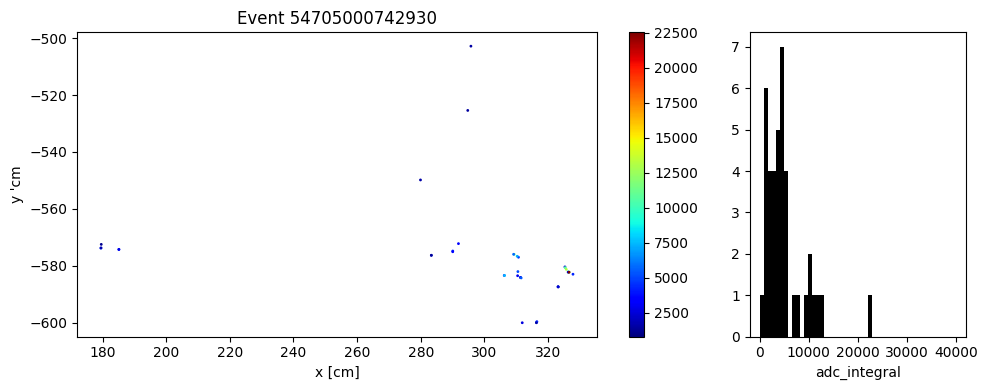

In [308]:
ev = 54705000742930

display(cosmic_mcparts[cosmic_mcparts.event_uid == ev])
x = cosmic_tps[(cosmic_tps.event_uid == ev) & (cosmic_tps.bt_edep > 0)]

fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})
axs[0].scatter(x.bt_x, x.bt_y, c=x.adc_integral, s=1, cmap='jet')
axs[0].set_title(f"Event {ev}")
axs[0].set_xlabel("x [cm]")
axs[0].set_ylabel("y 'cm")
fig.colorbar(axs[0].collections[0], ax=axs[0])

axs[1].hist(x.adc_integral, bins=np.linspace(0, 40e3, 50), color='k')
axs[1].set_xlabel("adc_integral")

plt.tight_layout()
plt.show()


/var/folders/1s/mfxsnwp9275ft3r75z4zs6c80000gn/T/ipykernel_74111/1003634383.py:4: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0))) + b


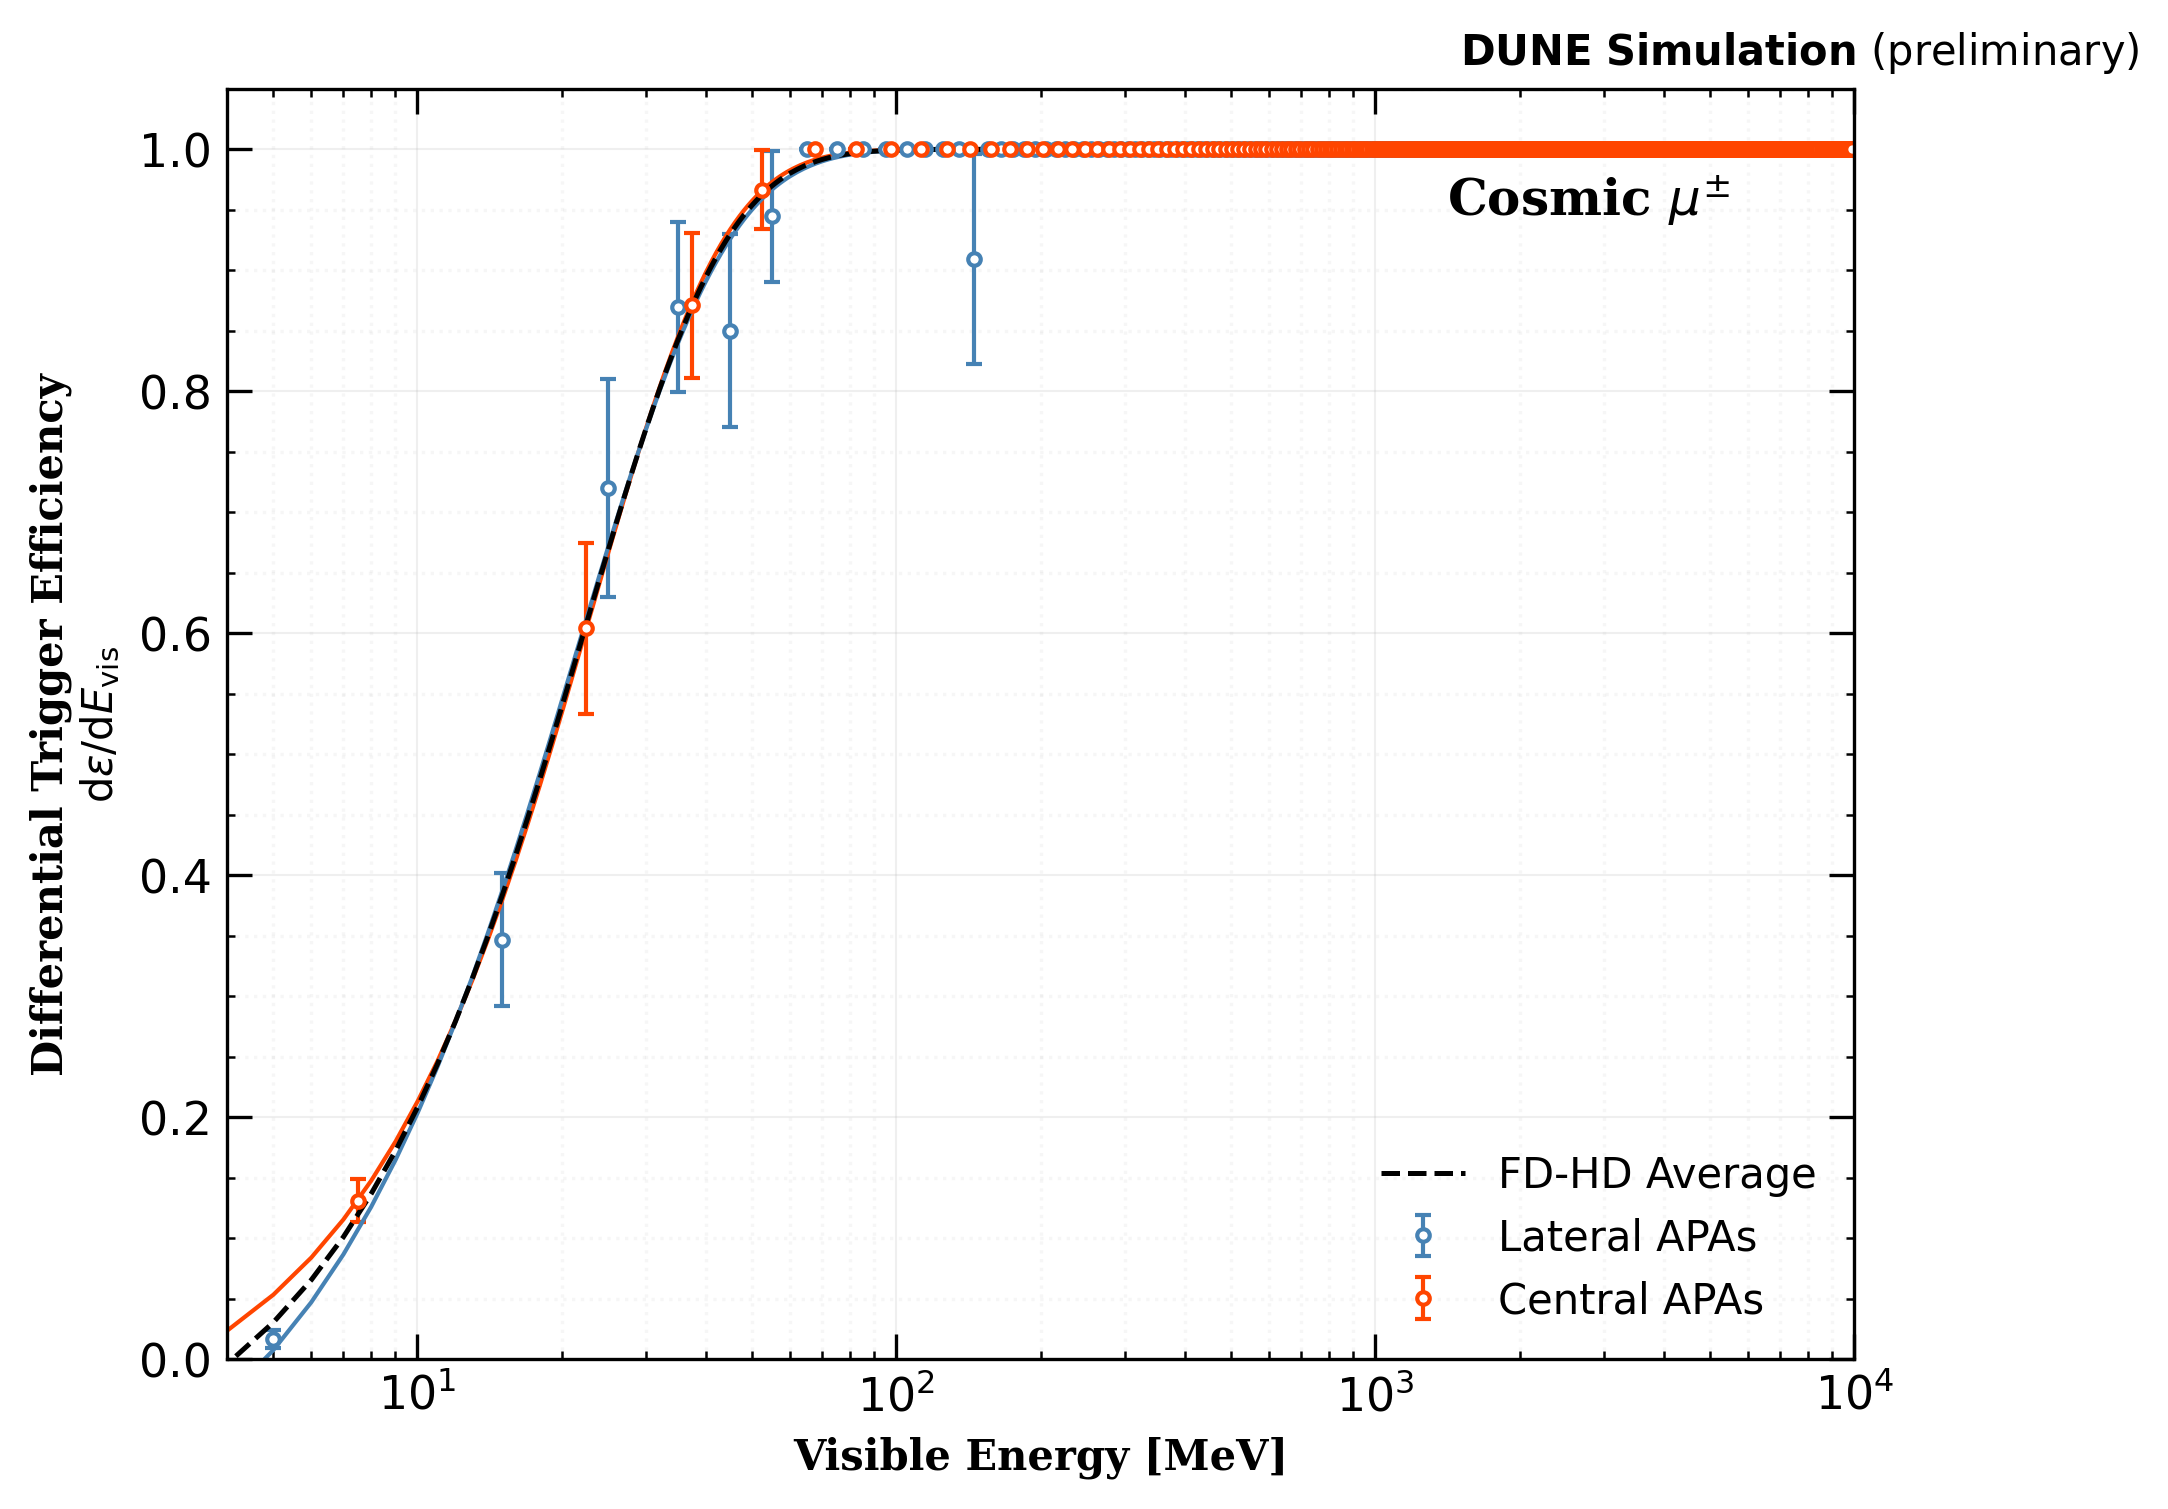

In [288]:
from scipy.optimize import curve_fit

def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

data_lat = [trig_cosmic_lat[trig_cosmic_lat.visible_energy> 1]]
data_cent = [trig_cosmic_cent[trig_cosmic_cent.visible_energy > 1]]
#fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=200, sharex=True, sharey=True)
fig, ax = plt.subplots(figsize=(7,5.5), dpi=300)
lines_for_legend = []

for idx in range(len(data_lat)):
    dx_lat = 10
    dx_cent =15
    max_eng = 1e4

    energies_lat = np.arange(0, max_eng, dx_lat)
    bin_centers_lat = energies_lat[:-1] + dx_lat / 2

    energies_cent = np.arange(0, max_eng, dx_cent)
    bin_centers_cent = energies_cent[:-1] + dx_cent / 2

    sensitivity_lat = []
    errors_lat = []
    df_lat = data_lat[idx]
    for energy_start in energies_lat[:-1]:
        upper = energy_start + dx_lat
        events_in_bin = df_lat[(df_lat.visible_energy >= energy_start) & (df_lat.visible_energy < upper)]
        accepted_events_in_bin = events_in_bin[events_in_bin.flag == 2]

        n = events_in_bin.event_uid.nunique()
        k = accepted_events_in_bin.event_uid.nunique()

        if n > 0:
            sens = k / n
            err = np.sqrt(sens * (1 - sens) / n)
        else:
            sens = np.nan
            err = 0

        sensitivity_lat.append(sens)
        errors_lat.append(err)

    sensitivity_cent = []
    errors_cent = []
    df_cent = data_cent[idx]
    for energy_start in energies_cent[:-1]:
        upper = energy_start + dx_cent
        events_in_bin = df_cent[(df_cent.visible_energy >= energy_start) & (df_cent.visible_energy < upper)]
        accepted_events_in_bin = events_in_bin[events_in_bin.flag == 2]

        n = events_in_bin.event_uid.nunique()
        k = accepted_events_in_bin.event_uid.nunique()

        if n > 0:
            sens = k / n
            err = np.sqrt(sens * (1 - sens) / n)
        else:
            sens = np.nan
            err = 0

        sensitivity_cent.append(sens)
        errors_cent.append(err)

    bin_centers_lat = np.array(bin_centers_lat)
    sensitivity_lat = np.array(sensitivity_lat)
    errors_lat = np.array(errors_lat)

    bin_centers_cent = np.array(bin_centers_cent)
    sensitivity_cent = np.array(sensitivity_cent)
    errors_cent = np.array(errors_cent)

    mask_lat = ~np.isnan(sensitivity_lat)
    mask_cent = ~np.isnan(sensitivity_cent)

    try:
        popt_lat, _ = curve_fit(sigmoid, bin_centers_lat[mask_lat], sensitivity_lat[mask_lat], p0=[1, 10, 1, 0], maxfev=1000)
    except:
        popt_lat = [1, 10, 1, 0]
    try:
        popt_cent, _ = curve_fit(sigmoid, bin_centers_cent[mask_cent], sensitivity_cent[mask_cent], p0=[1, 10, 1, 0], maxfev=1000)
    except:
        popt_cent = [1, 10, 1, 0]

    x_fit = np.linspace(0, 1000, 1000)
    y_fit_lat = sigmoid(x_fit, *popt_lat)
    y_fit_cent = sigmoid(x_fit, *popt_cent)
    y_fit_mean = (y_fit_lat + y_fit_cent) / 2



    ax.errorbar(bin_centers_lat, sensitivity_lat, yerr=errors_lat, fmt='o', capsize=2, markersize=3,markerfacecolor='white', elinewidth=1, color=cl, label='Lateral APAs')
    ax.errorbar(bin_centers_cent, sensitivity_cent, yerr=errors_cent, fmt='o', capsize=2, markersize=3,markerfacecolor='white', elinewidth=1, color=cc, label = 'Central APAs')
    line_cent, = ax.plot(x_fit, y_fit_cent, color=cc, linewidth=1)
    line_lat, = ax.plot(x_fit, y_fit_lat, color=cl, linewidth=1)



    line_mean, = ax.plot(x_fit, y_fit_mean, color='black', linewidth=1.2, linestyle='--', label ="FD-HD Average")

    if idx == 0: lines_for_legend = [line_cent, line_lat, line_mean]

    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0,1e5)
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.2)
    ax.grid(True, which='minor', linestyle=':', alpha =0.1)
    ax.set_xscale('log')
    ax.set_xlim(4,max_eng)
    ax.set_xlabel("Visible Energy [MeV]", fontweight='bold', family='serif')
    ax.set_ylabel(r"Differential Trigger Efficiency" + "\n" + r"$\mathrm{d}\varepsilon / \mathrm{d}E_\mathrm{vis}$",  fontweight='bold',  family='serif')
    ax.legend( frameon=False, loc='lower right',  ncol=1)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length =6)
    ax.text(1.5e3, 1.07, r'$\bf{DUNE\ Simulation}$ (preliminary)')
    ax.minorticks_on()
    ax.text(0.75, 0.90, r"Cosmic $\mu^{\pm}$", transform=ax.transAxes, fontsize=12, fontweight='bold', family='serif')
    ax.legend(loc = 'lower right', frameon = False)
plt.show()

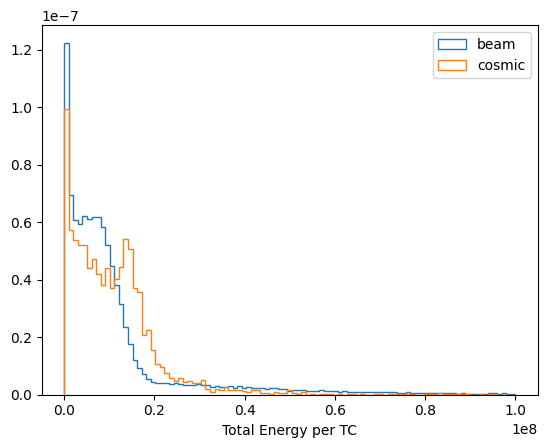

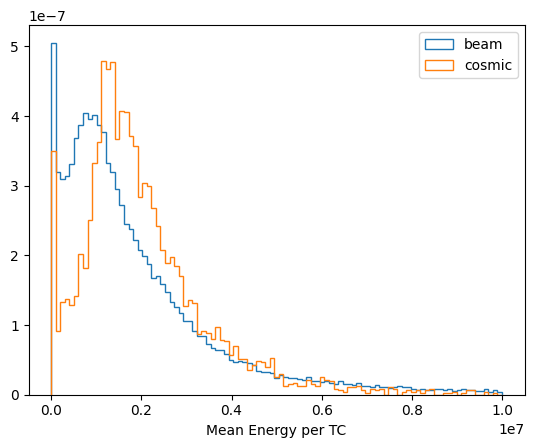

In [225]:
bins = np.linspace(0,0.1e9, 100)
params = {"bins": bins, "density":True, "histtype":'step'}

plt.hist(trig_beam_nue_cent.groupby("event_uid").total_window_energy.sum(), **params, label ='beam')
plt.hist(cTAs_cosmic.groupby("event").total_window_energy.sum(), **params, label = 'cosmic')
plt.legend()
plt.xlabel("Total Energy per TC")
plt.show()

bins = np.linspace(0,0.1e8, 100)
params = {"bins": bins, "density":True, "histtype":'step'}

plt.hist(trig_beam_nue_cent.groupby("event_uid").total_window_energy.sum()/trig_beam_nue_cent.groupby("event_uid").size(), **params, label ='beam')
plt.hist(cTAs_cosmic.groupby("event").total_window_energy.sum()/cTAs_cosmic.groupby("event").size(), **params, label = 'cosmic')
plt.legend()
plt.xlabel("Mean Energy per TC")
plt.show()

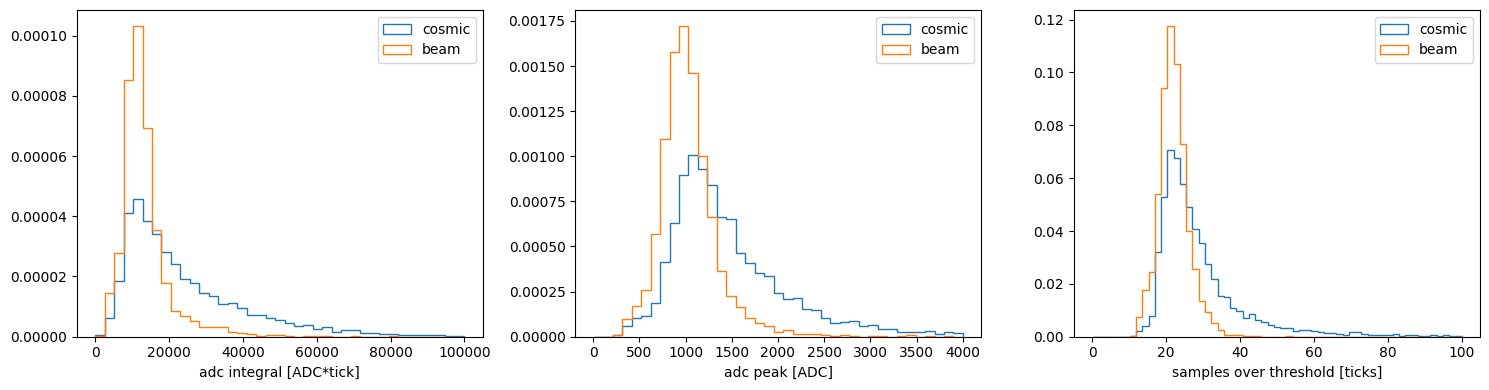

In [237]:


fig, axs = plt.subplots(1, 3, figsize=(15, 4))


params = {"bins": np.linspace(8, 100e3, 40), "density": True, "histtype": 'step'}
axs[0].hist(cTPs_cosmic.groupby("event").adc_integral.mean(), **params, label='cosmic')
axs[0].hist(beam_nue_ctps.groupby("event_uid").adc_integral.mean(), **params, label='beam')
axs[0].set_xlabel("adc integral [ADC*tick]")
axs[0].legend()

params = {"bins": np.linspace(8, 4e3, 40), "density": True, "histtype": 'step'}
axs[1].hist(cTPs_cosmic.groupby("event").adc_peak.mean(), **params, label='cosmic')
axs[1].hist(beam_nue_ctps.groupby("event_uid").adc_peak.mean(), **params, label='beam')
axs[1].set_xlabel("adc peak [ADC]")
axs[1].legend()

params = {"bins": np.linspace(0, 100, 60), "density": True, "histtype": 'step'}
axs[2].hist(cTPs_cosmic.groupby("event").samples_over_threshold.mean(), **params, label='cosmic')
axs[2].hist(beam_nue_ctps.groupby("event_uid").samples_over_threshold.mean(), **params, label='beam')
axs[2].set_xlabel("samples over threshold [ticks]")
axs[2].legend()

plt.tight_layout()
plt.show()
